In [1]:
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.datasets import make_classification, make_moons, make_regression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    recall_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

LINESPACE_COUNT = 500
MAX_EPOCH = 1000
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

### Простой линейный классификатор двумерной выборки (make_moons)

In [2]:
X, y = make_moons(
    n_samples=300,
    noise=0.1,
    random_state=SEED,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

X_train_tn = torch.FloatTensor(X_train)
X_test_tn = torch.FloatTensor(X_test)

y_train_tn = torch.FloatTensor(y_train).reshape(-1, 1)

lin_model = nn.Linear(2, 1)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(lin_model.parameters(), lr=0.01)

for epoch in range(MAX_EPOCH):
    optimizer.zero_grad()

    y_pred = lin_model(X_train_tn)
    loss = criterion(y_pred, y_train_tn)

    loss.backward()
    optimizer.step()

with torch.no_grad():
    logits = lin_model(X_test_tn)
    probs = torch.sigmoid(logits)
    y_pred = (probs >= 0.5).float()

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.3f}")

Test accuracy: 0.800


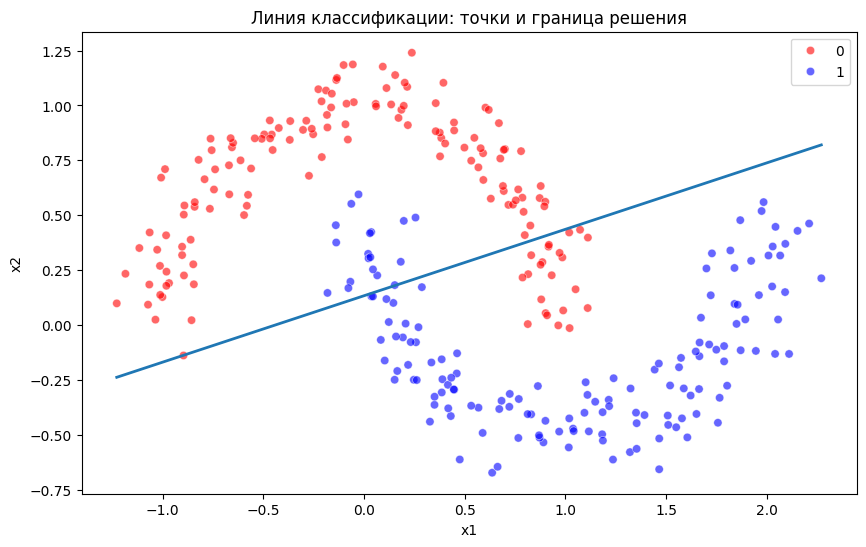

Параметры модели
Веса: [ 1.2955257 -4.2813506]
Смещение: 0.5699695348739624


In [3]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X[:,0], y=X[:,1],
    hue=y,
    palette=["red", "blue"],
    alpha=0.6,
)

w = lin_model.weight.data.numpy()[0]
b = lin_model.bias.data.numpy()[0]

x_line = np.linspace(X[:,0].min(), X[:,0].max(), 10)
y_line = -(w[0] * x_line + b) / w[1]

plt.plot(x_line, y_line, linewidth=2)

plt.title("Линия классификации: точки и граница решения")
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

print("Параметры модели")
print(f"Веса: {w}")
print(f"Смещение: {b}")

### Реализация активационных функций и их визуализация

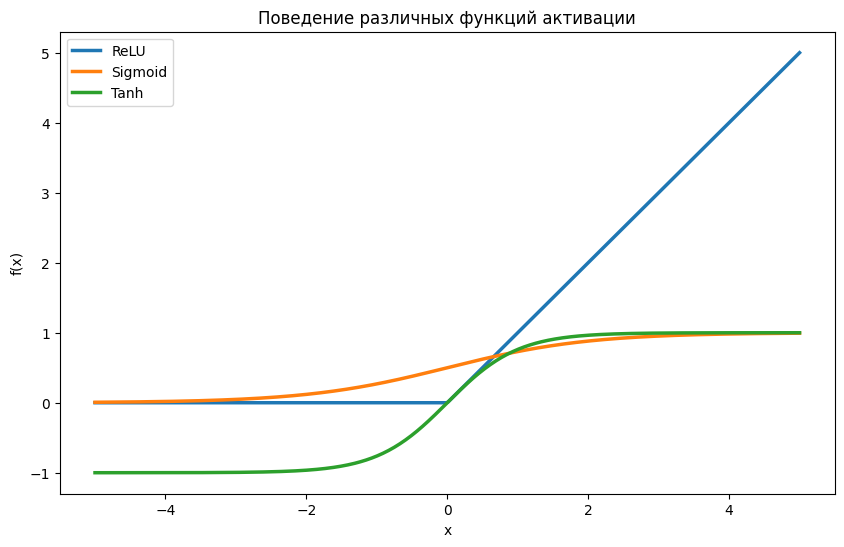

In [4]:
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

x = np.linspace(-5, 5, LINESPACE_COUNT)

plt.figure(figsize=(10, 6))

sns.lineplot(x=x, y=relu(x), label="ReLU", linewidth=2.5)
sns.lineplot(x=x, y=sigmoid(x), label="Sigmoid", linewidth=2.5)
sns.lineplot(x=x, y=tanh(x), label="Tanh", linewidth=2.5)

plt.title("Поведение различных функций активации")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.show()

### Forward pass на numpy

In [ ]:
def relu_np(z):
    return np.maximum(0, z)

def sigmoid_np(z):
    return 1 / (1 + np.exp(-z))

rng = np.random.default_rng(SEED)

batch_size, input_size, hidden_size, output_size = 32, 2, 8, 1

X = rng.normal(0, 1, size=(batch_size, input_size))

W1 = rng.normal(0, 0.1, size=(input_size, hidden_size))
b1 = np.zeros((1, 8))
W2 = rng.normal(0, 0.1, size=(hidden_size, output_size))
b2 = np.zeros((1, 1))

z1 = X @ W1 + b1
h1 = relu_np(z1)
z2 = h1 @ W2 + b2
y_pred = sigmoid_np(z2)

print("Input batch shape:", X.shape)
print("Hidden activations shape:", h1.shape)
print("Output shape:", y_pred.shape)
print("\nПример выхода (первые 5 примеров):")
print(y_pred[:5])

Input batch shape: (32, 2)
Hidden activations shape: (32, 8)
Output shape: (32, 1)

Пример выхода (первые 5 примеров):
[[0.49922944]
 [0.49723557]
 [0.49786795]
 [0.49970402]
 [0.49984434]]


### Broadcasting

In [ ]:
X = np.random.randn(10, 5)
w = np.random.randn(5)
b = np.array([0.3])

z = X @ w + b
print("w.shape:", w.shape)
print("X.shape:", X.shape)
print("b.shape:", b.shape)
print("z.shape:", z.shape)

w_col = w.reshape(-1, 1)
z_wrong = X @ w_col + b
print("Если w сделать столбцом, получаем shape:", z_wrong.shape)

z_fixed = z_wrong.reshape(-1)
print("Исправили reshape ->", z_fixed.shape)

w.shape: (5,)
X.shape: (10, 5)
b.shape: (1,)
z.shape: (10,)
Если w сделать столбцом, получаем shape: (10, 1)
Исправили reshape -> (10,)


### Решение задачи XOR

In [7]:
X_xor = torch.tensor([[0.,0.],
                      [0.,1.],
                      [1.,0.],
                      [1.,1.]], dtype=torch.float32)
y_xor = torch.tensor([[0.],
                      [1.],
                      [1.],
                      [0.]], dtype=torch.float32)

class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 1)
        self.act = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

model_xor = XORNet()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_xor.parameters(), lr=0.1)


loss_history = []
for epoch in range(MAX_EPOCH):
    optimizer.zero_grad()
    
    y_pred = model_xor(X_xor)
    loss = criterion(y_pred, y_xor)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())

with torch.no_grad():
    logits = model_xor.forward(X_xor)
    probs = torch.sigmoid(logits)
    y_pred = (probs >= 0.5).float()
    acc = accuracy_score(y_xor, y_pred)

print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Accuracy:   {acc:.3f}")
print("Predictions (prob):", probs.view(-1).tolist())

colors = [
    "red" if y == 0 else "blue"
    for y in y_xor.view(-1)
]

with torch.no_grad():
    xx, yy = np.meshgrid(
        np.linspace(0, 1, 100),
        np.linspace(0, 1, 100),
    )
    grid = torch.FloatTensor(np.c_[
        xx.ravel(),
        yy.ravel(),
    ])

    grid_logits = model_xor(grid)
    grid_probs = torch.sigmoid(grid_logits).numpy().reshape(xx.shape)

Final loss: 0.000011
Accuracy:   1.000
Predictions (prob): [1.9776762201217934e-05, 0.9999903440475464, 0.9999949932098389, 8.578968845540658e-06]


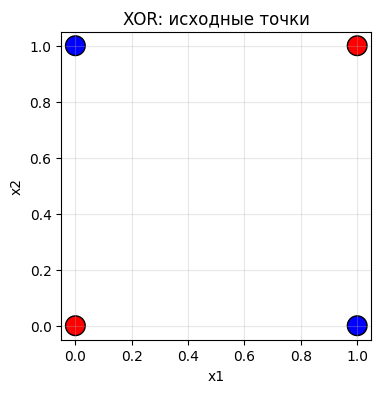

In [8]:
plt.figure(figsize=(4, 4))

plt.scatter(X_xor[:,0], X_xor[:,1], c=colors, s=200, edgecolor="k")

plt.title("XOR: исходные точки")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.show()

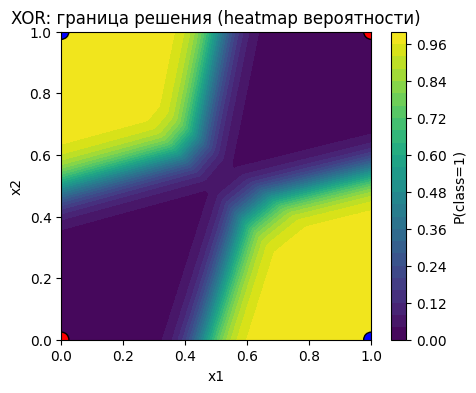

In [9]:
plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, grid_probs, levels=30)
plt.colorbar(label="P(class=1)")

plt.scatter(X_xor[:,0], X_xor[:,1], c=colors, s=120, edgecolor="k")

plt.title("XOR: граница решения (heatmap вероятности)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

### Визуализация преобразования входных признаков в скрытом слое

XORNet(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
  (act): ReLU()
)

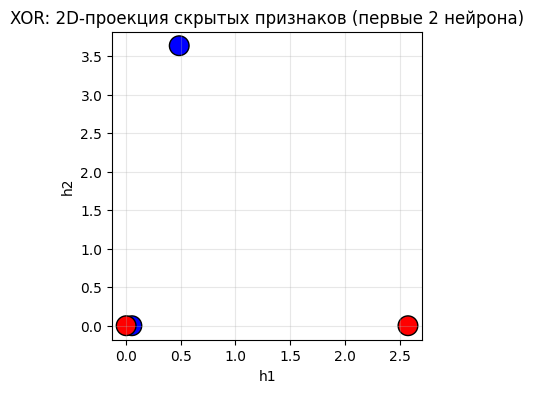

In [10]:
display(model_xor.eval())

with torch.no_grad():
    z = model_xor.fc1(X_xor)
    hidden = model_xor.act(z)

plt.figure(figsize=(4, 4))

plt.scatter(hidden[:,0], hidden[:,1], c=colors, s=200, edgecolor="black")

plt.title("XOR: 2D-проекция скрытых признаков (первые 2 нейрона)")
plt.xlabel("h1")
plt.ylabel("h2")
plt.grid(True, alpha=0.3)
plt.show()

**ВЫВОД**:  

После преобразования скрытым слоем `(4 нейрона)` классы стали линейно разделимыми, но в проекции на `первые два нейрона` это не видно, так как разделимость достигается за счет использования всех четырех нейронов.

### Полный цикл работы с датасетом `make_moons`

In [11]:
X, y = make_moons(n_samples=300, noise=0.1, random_state=SEED)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tn = torch.FloatTensor(X_train_scaled)
X_test_tn = torch.FloatTensor(X_test_scaled)
y_train_tn = torch.FloatTensor(y_train).reshape(-1, 1)
y_test_tn = torch.FloatTensor(y_test).reshape(-1, 1)


class MNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)
        self.act = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)
        return x

m_model = MNet()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(m_model.parameters(), lr=0.01)

loss_history = []
for epoch in range(MAX_EPOCH):
    optimizer.zero_grad()

    y_pred = m_model(X_train_tn)
    loss = criterion(y_pred, y_train_tn)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

with torch.no_grad():
    probs = torch.sigmoid(m_model(X_test_tn))
    y_test_pred = (probs >= 0.5).float()
    test_acc = accuracy_score(y_test, y_test_pred)

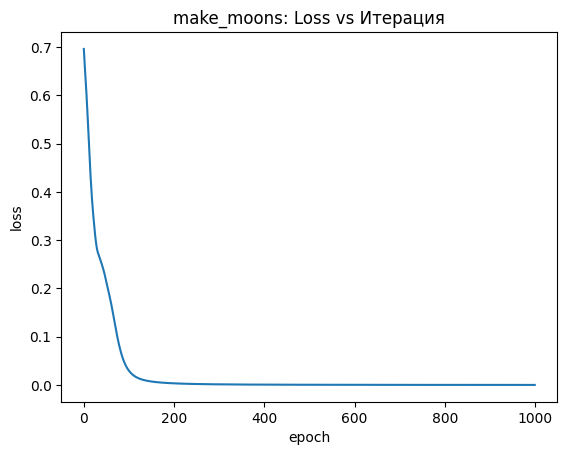

In [12]:
sns.lineplot(loss_history)

plt.title("make_moons: Loss vs Итерация")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

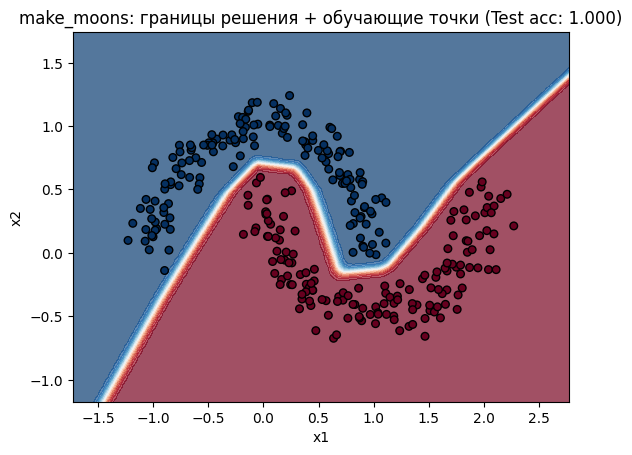

In [13]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100),
)

grid = torch.FloatTensor(np.c_[
    xx.ravel(),
    yy.ravel(),
])
grid_scaled = torch.FloatTensor(scaler.transform(grid.numpy()))

with torch.no_grad():
    grid_probs = torch.sigmoid(m_model(grid_scaled)).numpy().reshape(xx.shape)

plt.contourf(xx, yy, grid_probs, levels=20, cmap="RdBu_r", alpha=0.7)
plt.scatter(X[:,0], X[:,1], c=y, cmap="RdBu_r", edgecolor="black", s=30)
plt.title(
    "make_moons: границы решения + обучающие точки "
    f"(Test acc: {test_acc:.3f})"
)
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

### Реализация комбинированной функии потерь (MSE + MAE)

In [14]:
X, y = make_regression(
    n_samples=1000,
    n_features=12,
    noise=0.1,
    random_state=SEED,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tn = torch.FloatTensor(X_train_scaled)
X_test_tn = torch.FloatTensor(X_test_scaled)
y_train_tn = torch.FloatTensor(y_train).reshape(-1, 1)
y_test_tn = torch.FloatTensor(y_test).reshape(-1, 1)

In [15]:
def mse_loss(pred, target):
    return torch.mean((pred - target) ** 2)

def mae_loss(pred, target):
    return torch.mean(torch.abs(pred - target))

def combined_loss(pred, target, alpha=0.7):
    mse = mse_loss(pred, target)
    mae = mae_loss(pred, target)
    return alpha * mse + (1 - alpha) * mae

class CombineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(12, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)
        return x


combine_model_base = CombineNet()
combine_model_mse = CombineNet()
combine_model_mae = CombineNet()

models_map = {
    "comb": {
        "model": combine_model_base,
        "loss": combined_loss,
        "optimizer": torch.optim.Adam(combine_model_base.parameters(), lr=0.01),
        "history": [],
    },
    "mse": {
        "model": combine_model_mse,
        "loss": mse_loss,
        "optimizer": torch.optim.Adam(combine_model_mse.parameters(), lr=0.01),
        "history": [],
    },
    "mae": {
        "model": combine_model_mae,
        "loss": mae_loss,
        "optimizer": torch.optim.Adam(combine_model_mae.parameters(), lr=0.01),
        "history": [],
    },
}

for model in models_map.values():

    current_model = model.get("model")
    current_loss = model.get("loss")
    current_opt = model.get("optimizer")
    current_loss_history = model.get("history")
    
    for epoch in range(100):
        current_opt.zero_grad()

        y_pred = current_model(X_train_tn)
        loss = current_loss(y_pred, y_train_tn)

        loss.backward()
        current_opt.step()

        current_loss_history.append(loss.item())


In [16]:
def regression_metrics(y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(
        f"RMSE: {rmse:.3f}\n"
        f"MAE: {mae:.3f}\n"
    )

with torch.no_grad():
    y_pred_comb = models_map["comb"]["model"](X_test_tn)
    y_pred_mse = models_map["mse"]["model"](X_test_tn)
    y_pred_mae = models_map["mae"]["model"](X_test_tn)

print("Метрики на комбинированном подходе:")
regression_metrics(y_test, y_pred_comb)

print("Метрики на MSE:")
regression_metrics(y_test, y_pred_mse)

print("Метрики на MAE:")
regression_metrics(y_test, y_pred_mae)

Метрики на комбинированном подходе:
RMSE: 15.941
MAE: 12.198

Метрики на MSE:
RMSE: 16.479
MAE: 12.775

Метрики на MAE:
RMSE: 14.962
MAE: 10.902



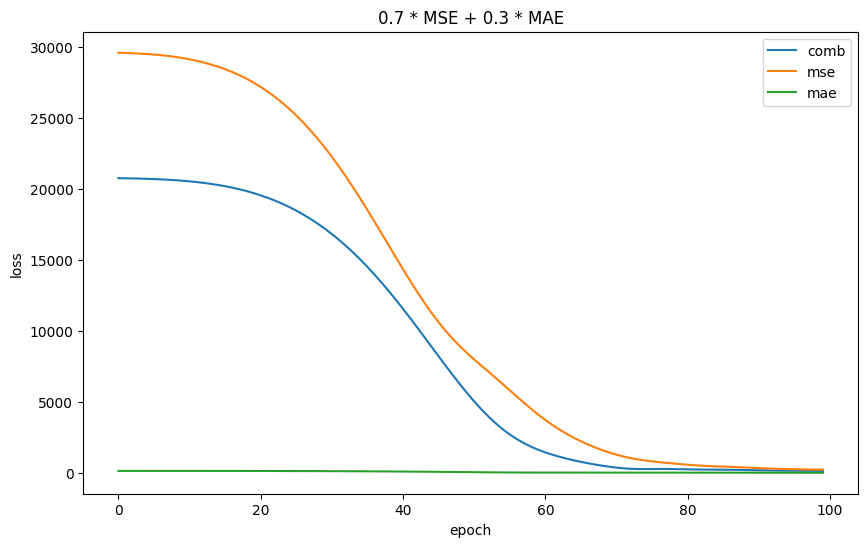

In [17]:
plt.figure(figsize=(10, 6))

sns.lineplot(models_map["comb"]["history"], label="comb", linewidth=1.5)
sns.lineplot(models_map["mse"]["history"], label="mse", linewidth=1.5)
sns.lineplot(models_map["mae"]["history"], label="mae", linewidth=1.5)

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("0.7 * MSE + 0.3 * MAE")

plt.show()

### Работа с дисбалансом классов

In [18]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    weights=[0.9, 0.1],
    random_state=SEED,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tn = torch.FloatTensor(X_train_scaled)
X_test_tn = torch.FloatTensor(X_test_scaled)
y_train_tn = torch.LongTensor(y_train)
y_test_tn = torch.LongTensor(y_test)

In [19]:
class WCENet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 2)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)
        return x

unique, counts = np.unique(y_train, return_counts=True)
weights = len(unique) / counts
weights = torch.FloatTensor(weights)

wce_model = WCENet()
wce_model_v2 = WCENet()

models_map = {
    "with_weights": {
        "model": wce_model,
        "loss": nn.CrossEntropyLoss(weight=weights),
        "optimizer": torch.optim.Adam(wce_model.parameters(), lr=0.01),
        "history": [],
    },
    "without_weights": {
        "model": wce_model_v2,
        "loss": nn.CrossEntropyLoss(),
        "optimizer": torch.optim.Adam(wce_model_v2.parameters(), lr=0.01),
        "history": [],
    },
}

for model in models_map.values():

    current_model = model.get("model")
    current_loss = model.get("loss")
    current_opt = model.get("optimizer")
    current_loss_history = model.get("history")
    
    for epoch in range(100):
        current_opt.zero_grad()

        y_pred = current_model(X_train_tn)
        loss = current_loss(y_pred, y_train_tn)

        loss.backward()
        current_opt.step()

        current_loss_history.append(loss.item())

with torch.no_grad():
    y_pred = models_map["with_weights"]["model"](X_test_tn)
    y_probs = torch.softmax(y_pred, dim=1)
    y_test_pred = torch.argmax(y_probs, dim=1)
    recall_with_weights = recall_score(y_test, y_test_pred.numpy())
    
    conf_with_weights = confusion_matrix(y_test, y_test_pred.numpy())

with torch.no_grad():
    y_pred = models_map["without_weights"]["model"](X_test_tn)
    y_probs = torch.softmax(y_pred, dim=1)
    y_test_pred = torch.argmax(y_probs, dim=1)
    recall_without_weights = recall_score(y_test, y_test_pred.numpy())
    
    conf_without_weights = confusion_matrix(y_test, y_test_pred.numpy())

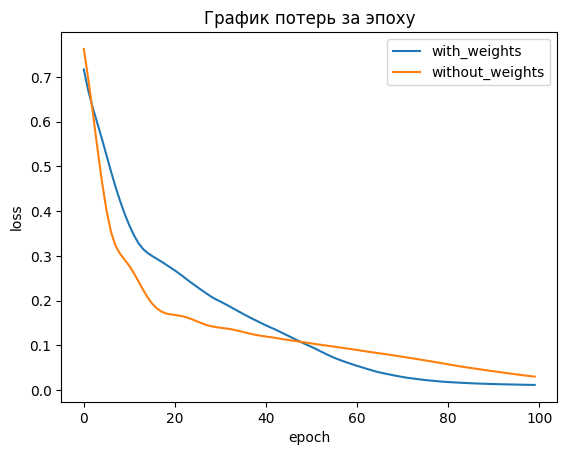

In [20]:
sns.lineplot(models_map["with_weights"]["history"], label="with_weights")

sns.lineplot(models_map["without_weights"]["history"], label="without_weights")

plt.title("График потерь за эпоху")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.show()

In [21]:
print(f"Recall для модели с weigths: {recall_with_weights:.3f}")
print(f"Recall для модели без weigths: {recall_without_weights:.3f}")

Recall для модели с weigths: 0.700
Recall для модели без weigths: 0.600


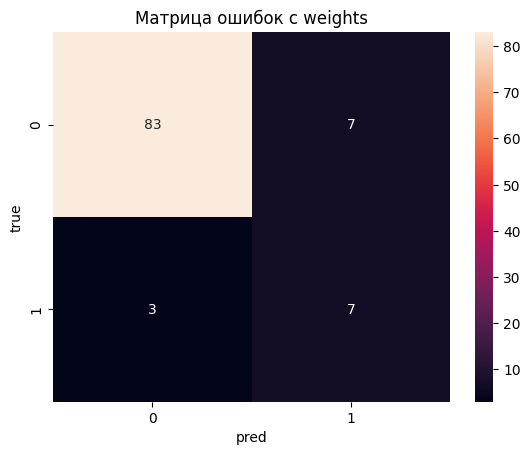

In [22]:
sns.heatmap(conf_with_weights, annot=True)

plt.title("Матрица ошибок с weights")
plt.xlabel("pred")
plt.ylabel("true")

plt.show()

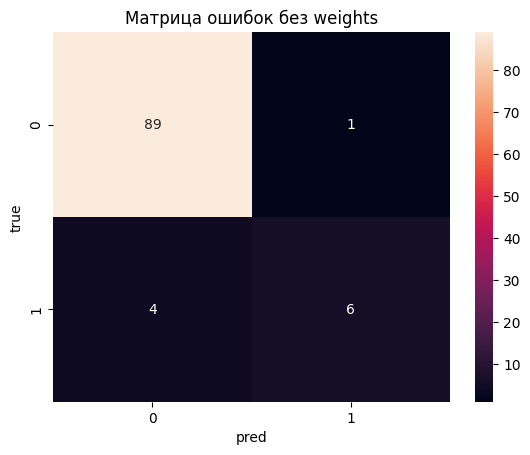

In [23]:
sns.heatmap(conf_without_weights, annot=True)

plt.title("Матрица ошибок без weights")
plt.xlabel("pred")
plt.ylabel("true")

plt.show()

**ВЫВОД:**  

Взвешивание классов в функции потерь повысило `recall` с `0.6` до `0.7`, так как эти веса усиливают штраф за ошибки на редком классе, поэтому модель меньше игнорирует класс 1.